In [14]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler

# Stop any pre-existing Spark session and start a clean local session
active_spark = SparkSession.getActiveSession()
if active_spark is not None:
    active_spark.stop()

spark = SparkSession.builder \
    .appName("Section5-IF-Fallback") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

data = [
    (1000000, 5, 0.3),
    (1020000, 6, 0.31),
    (980000, 5, 0.32),
    (1010000, 6, 0.30),
    (990000, 5, 0.31),
    (1000000, 50, 0.95)  # true anomaly
]

df = spark.createDataFrame(data, ["nav", "trades", "exposure"])
assembler = VectorAssembler(
    inputCols=["nav", "trades", "exposure"],
    outputCol="features"
)
df_features = assembler.transform(df)

# Fallback: use sklearn IsolationForest to avoid SynapseML JVM dependency issues
from sklearn.ensemble import IsolationForest as SkIsolationForest
import pandas as pd

pdf = df_features.select("nav", "trades", "exposure").toPandas()
X = pdf[["nav", "trades", "exposure"]]

sk_iforest = SkIsolationForest(
    contamination=0.16,
    n_estimators=100,
    random_state=42
)
sk_iforest.fit(X)

# sklearn: -1 anomaly, 1 normal; map to Spark-like 1 anomaly, 0 normal
pdf["anomalyScore"] = -sk_iforest.decision_function(X)
pdf["anomaly"] = (sk_iforest.predict(X) == -1).astype(int)

result_df = spark.createDataFrame(pdf)
result_df.select("nav", "trades", "exposure", "anomalyScore", "anomaly").show(truncate=False)

26/04/07 13:31:05 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/07 13:31:05 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/07 13:31:05 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


+-------+------+--------+---------------------+-------+
|nav    |trades|exposure|anomalyScore         |anomaly|
+-------+------+--------+---------------------+-------+
|1000000|5     |0.3     |-0.11854205179029703 |0      |
|1020000|6     |0.31    |-0.03467933345897978 |0      |
|980000 |5     |0.32    |-0.037679037542780014|0      |
|1010000|6     |0.3     |-0.08138316438595222 |0      |
|990000 |5     |0.31    |-0.13010065826598083 |0      |
|1000000|50    |0.95    |0.138717333835919    |1      |
+-------+------+--------+---------------------+-------+



In [15]:
import random

data = [100000 + random.randint(-5000, 5000) for _ in range(55)]
data.append(300000)  # anomaly

print(data)

rule_anomalies = [x for x in data if x < 0 or x > 500000]

print("Rule anomalies:", rule_anomalies)

[98858, 101615, 95021, 100449, 102471, 96449, 99390, 101726, 96321, 97636, 97719, 103801, 95817, 102467, 98415, 102595, 104254, 102161, 98905, 101187, 96983, 104906, 103657, 95831, 100763, 95786, 95255, 95608, 97956, 99765, 104279, 102752, 101178, 100234, 102477, 104323, 98868, 100686, 103972, 103334, 103765, 97444, 101335, 101701, 96204, 100156, 103629, 102464, 104062, 103108, 96667, 98673, 100035, 98181, 104367, 300000]
Rule anomalies: []


IQR anomalies: [300000]


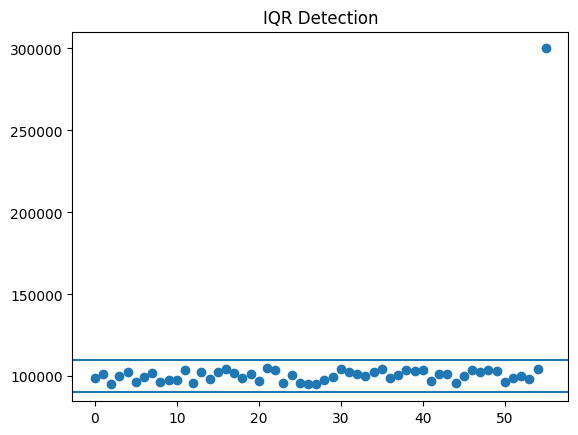

In [16]:
import numpy as np
import matplotlib.pyplot as plt

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

iqr_anomalies = [x for x in data if x < lower or x > upper]

print("IQR anomalies:", iqr_anomalies)


plt.figure()
plt.scatter(range(len(data)), data)

plt.axhline(upper)
plt.axhline(lower)

plt.title("IQR Detection")
plt.show()

IQR: [140]
Z-score: [140]


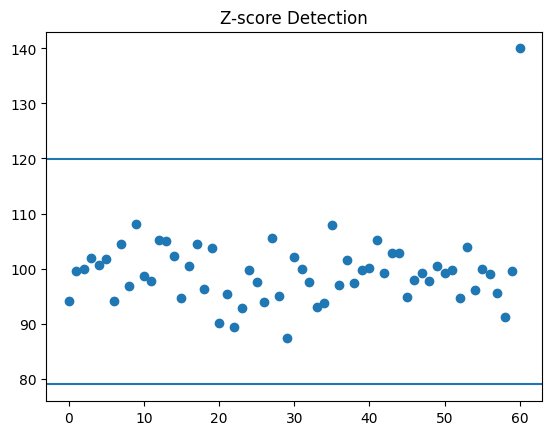

In [17]:
data = list(np.random.normal(100, 5, 60))
data.append(140)  # anomaly

q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)

iqr = q3 - q1

iqr_anomalies = [x for x in data if x < q1 - 1.5*iqr or x > q3 + 1.5*iqr]

print("IQR:", iqr_anomalies)

mean = np.mean(data)
std = np.std(data)

z_anomalies = [x for x in data if abs((x - mean)/std) > 3]

print("Z-score:", z_anomalies)

plt.figure()
plt.scatter(range(len(data)), data)

plt.axhline(mean + 3*std)
plt.axhline(mean - 3*std)

plt.title("Z-score Detection")
plt.show()

Z-score: [1000]
Robust Z: [36.49352482435053, 37.1730002341864, 57.59860449873045, 40.01440983603111, 1000]


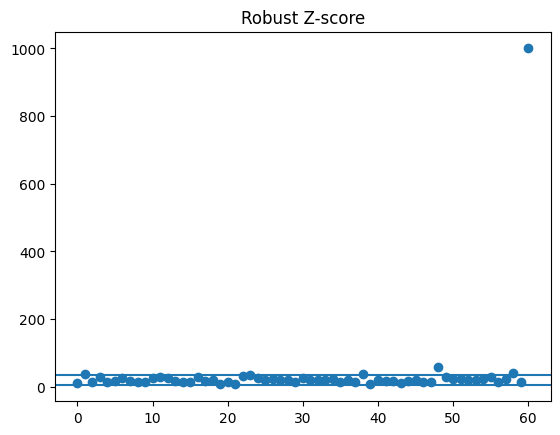

In [18]:
data = list(np.random.lognormal(3, 0.4, 60))
data.append(1000)  # anomaly

mean = np.mean(data)
std = np.std(data)

z_anomalies = [x for x in data if abs((x - mean)/std) > 3]

print("Z-score:", z_anomalies)

median = np.median(data)
mad = np.median([abs(x - median) for x in data])

robust_anomalies = [x for x in data if abs((x - median)/mad) > 3]

print("Robust Z:", robust_anomalies)

plt.figure()
plt.scatter(range(len(data)), data)

plt.axhline(median + 3*mad)
plt.axhline(median - 3*mad)

plt.title("Robust Z-score")
plt.show()